In [ ]:
import sqlite3
import pandas as pd

DB = "./data/earnings.db"
conn = sqlite3.connect(DB)

pd.read_sql("SELECT 'connected' AS status", conn)


In [ ]:
def ticker_lookup(ticker: str) -> pd.DataFrame:
    ticker = ticker.strip().upper()
    return pd.read_sql(
        """
        SELECT ticker, sector, industry, mkt_value, asof_date
        FROM universe_factset_latest
        WHERE ticker = ?
        """,
        conn,
        params=(ticker,)
    )

ticker_lookup("KBH")


In [ ]:
def latest_zscores(ticker: str) -> pd.DataFrame:
    ticker = ticker.strip().upper()
    return pd.read_sql(
        """
        SELECT ticker, call_date,
               mpi_z, dqi_z, ssi_z, eri_z, lri_z,
               composite_score, call_stance
        FROM call_zscores_latest
        WHERE ticker = ?
        """,
        conn,
        params=(ticker,)
    )

latest_zscores("KBH")


In [ ]:
def zscore_history(ticker: str) -> pd.DataFrame:
    ticker = ticker.strip().upper()
    df = pd.read_sql(
        """
        SELECT call_date,
               mpi_z, dqi_z, ssi_z, eri_z, lri_z,
               composite_score, call_stance
        FROM call_zscores
        WHERE ticker = ?
        ORDER BY call_date
        """,
        conn,
        params=(ticker,)
    )
    df["call_date"] = pd.to_datetime(df["call_date"])
    return df

df_kbh = zscore_history("KBH")
df_kbh


In [ ]:
import matplotlib.pyplot as plt

def plot_zscores(df: pd.DataFrame, title: str):
    plt.figure()
    for col in ["mpi_z", "dqi_z", "ssi_z", "eri_z", "lri_z"]:
        if col in df.columns:
            plt.plot(df["call_date"], df[col], marker="o", label=col)
    plt.axhline(0)
    plt.title(title)
    plt.xlabel("Call Date")
    plt.ylabel("Z-Score")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_zscores(df_kbh, "KBH — Z-Scores Over Time")


In [ ]:
pd.read_sql(
    """
    SELECT *
    FROM industry_regime
    ORDER BY asof_utc DESC
    """,
    conn
)


In [ ]:
def rank_industry(industry_fs: str) -> pd.DataFrame:
    industry_fs = industry_fs.strip().upper()
    return pd.read_sql(
        """
        WITH latest_calls AS (
          SELECT ticker, MAX(call_date) AS call_date
          FROM earnings_calls
          WHERE ticker IS NOT NULL AND ticker != '' AND ticker != 'UNKNOWN'
          GROUP BY ticker
        ),
        latest_ind AS (
          SELECT e.ticker, e.industry_fs
          FROM earnings_calls e
          JOIN latest_calls lc ON lc.ticker=e.ticker AND lc.call_date=e.call_date
          WHERE e.industry_fs IS NOT NULL AND e.industry_fs != ''
        )
        SELECT li.industry_fs,
               z.ticker, z.call_date,
               z.composite_score, z.call_stance,
               z.mpi_z, z.dqi_z, z.ssi_z, z.eri_z, z.lri_z
        FROM latest_ind li
        JOIN call_zscores_latest z ON z.ticker = li.ticker
        WHERE upper(li.industry_fs) = ?
        ORDER BY z.composite_score DESC
        """,
        conn,
        params=(industry_fs,)
    )

rank_industry("HOMEBUILDING").head(20)


In [ ]:
conn.close()


In [ ]:
import sqlite3
import json

conn = sqlite3.connect("../data/earnings.db")

mechanics = {
    "primary_levers": [
        "activity / utilization (rig count, frac spreads, offshore cadence)",
        "pricing (dayrates, service pricing, pass-through success)",
        "backlog / bookings / book-to-bill and conversion",
        "mix (offshore vs land, international vs US, service mix)",
        "cost inflation / tariffs / input constraints",
        "working capital swings and liquidity"
    ],
    "demand_definition": "Demand = customer capex + activity indicators (utilization, backlog, bookings).",
    "pricing_mechanics": "Pricing power = dayrates/service pricing and pass-through vs costs; concessions = rate cuts/terms/mix.",
    "margin_mechanics": "Margins driven by utilization + mix + pricing vs cost inflation; fixed-cost absorption matters.",
    "visibility_proxy": "Backlog duration, contracted work, book-to-bill, project push-outs.",
    "risk_flags": [
        "pricing rollover / rate pressure",
        "inventory build / idle capacity",
        "tariff / supply-chain cost leakage",
        "customer budget cuts / push-outs",
        "working-capital drag"
    ]
}

conn.execute(
    "INSERT OR REPLACE INTO industry_profiles (industry_fs, mechanics_json) VALUES (?, ?)",
    ("ENERGY EQUIPMENT & SERVICES", json.dumps(mechanics))
)

conn.commit()
print("Seeded ENERGY EQUIPMENT & SERVICES")


In [ ]:
import pandas as pd

pd.read_sql(
    "SELECT industry_fs FROM industry_profiles",
    conn
)



In [ ]:
import sqlite3
conn = sqlite3.connect("../data/earnings.db")

dupes = conn.execute("""
SELECT ticker, call_date, COUNT(*) as n
FROM earnings_calls
GROUP BY ticker, call_date
HAVING n > 1
""").fetchall()

dupes[:10]


In [ ]:
import sqlite3, pandas as pd
conn = sqlite3.connect("../data/earnings.db")

pd.read_sql("PRAGMA table_info(earnings_calls);", conn)[["name","type"]]


In [ ]:
pd.read_sql("""
SELECT name, sql
FROM sqlite_master
WHERE type='index' AND name='ux_call_event';
""", conn)


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/earnings.db")  # adjust path if needed


In [ ]:
pd.read_sql("""
SELECT name, sql
FROM sqlite_master
WHERE type='index'
AND name='ux_call_event'
""", conn)


In [ ]:
pd.read_sql("""
SELECT ticker, call_date, event_type
FROM earnings_calls
LIMIT 5
""", conn)


In [ ]:
conn.execute("""
INSERT INTO earnings_calls
(ticker, company, industry, call_date, fiscal_year, fiscal_quarter,
 source, source_path, file_hash, raw_text, text_char_count, created_at_utc, event_type)
VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
""",
(
    "KBH",
    None,
    "HOMEBUILDING",
    "2025-12-18",
    2025,
    4,
    "pdf",
    "fake_path",
    "fake_hash_123",
    "fake text",
    10,
    "2026-02-04T00:00:00Z",
    "earnings_call"
))
conn.commit()


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/earnings.db")  # adjust path if needed


In [ ]:
pd.read_sql("""
SELECT DISTINCT ticker
FROM earnings_calls
WHERE industry_factset = 'ENERGY EQUIPMENT & SERVICES'
ORDER BY ticker
""", conn)


In [ ]:
import os
os.getcwd()


In [ ]:
pd.read_sql("""
SELECT industry_factset, COUNT(*) AS n_calls, COUNT(DISTINCT ticker) AS n_tickers
FROM earnings_calls
GROUP BY industry_factset
ORDER BY n_calls DESC
""", conn)


In [ ]:
pd.read_sql("""
SELECT ec.ticker,
       COUNT(es.id) AS n_deep
FROM earnings_calls ec
LEFT JOIN earnings_signatures es
  ON es.earnings_call_id = ec.id
 AND es.prompt_version = 'ees_deep_v1'
WHERE ec.industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY ec.ticker
ORDER BY ec.ticker
""", conn)


In [ ]:
pd.read_sql("""
SELECT industry_fs, deep_prompt_version, deep_schema_name, is_active
FROM industry_prompt_registry
WHERE industry_fs = 'ENERGY EQUIPMENT & SERVICES'
""", conn)



In [ ]:
import sqlite3
from datetime import datetime, timezone
import pandas as pd

conn = sqlite3.connect("../data/earnings.db")
now = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

industry = "ENERGY EQUIPMENT & SERVICES"

conn.execute("""
INSERT OR REPLACE INTO industry_prompt_registry
(industry_fs, deep_prompt_version, deep_system_prompt, deep_schema_name, is_active, updated_at_utc)
VALUES (?, ?, ?, ?, 1, ?)
""", (
    industry,
    "energy_services_deep_v1",
    "You are a senior Energy Equipment & Services analyst. Extract a deep structured signature from this transcript. "
    "Focus on: activity/utilization, backlog/bookings/book-to-bill and backlog duration, pricing/dayrates and pass-through, "
    "mix (offshore vs onshore, intl vs US), cost pressure/tariffs, margin outlook + primary driver, customer capex tone/visibility, "
    "working capital and cash conversion, balance sheet stress/liquidity/leverage, and guidance action with timing/visibility. "
    "Be conservative; use 'unclear' when not supported. Provide short supporting quotes (<=25 words).",
    "EnergyServicesDeepSignatureV1",
    now
))

conn.commit()
print("OK: registry seeded for", industry)


In [ ]:
pd.read_sql("""
SELECT industry_fs, deep_prompt_version, deep_schema_name, is_active
FROM industry_prompt_registry
WHERE industry_fs = 'ENERGY EQUIPMENT & SERVICES'
""", conn)


In [ ]:
pd.read_sql("""
SELECT DISTINCT industry_factset
FROM earnings_calls
WHERE industry_factset IS NOT NULL
""", conn)



In [ ]:
pd.read_sql("""
SELECT industry_fs, regime_badge
FROM industry_regime
""", conn)


In [ ]:
pd.read_sql("""
SELECT industry_factset, COUNT(*) as n_calls
FROM earnings_calls
GROUP BY industry_factset
""", conn)


In [ ]:
pd.read_sql("""
SELECT industry_factset, COUNT(*) as n_calls
FROM earnings_calls
GROUP BY industry_factset
""", conn)


In [ ]:
pd.read_sql("""
SELECT e.industry_factset,
       COUNT(z.composite_score) as n_scored
FROM earnings_calls e
JOIN call_zscores z ON e.id = z.earnings_call_id
WHERE e.industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY e.industry_factset
""", conn)


In [ ]:
conn.executescript("""
UPDATE earnings_calls
SET
  sector_factset = (SELECT sector  FROM universe_factset_latest u WHERE u.ticker = earnings_calls.ticker),
  industry_factset = (SELECT industry FROM universe_factset_latest u WHERE u.ticker = earnings_calls.ticker),
  mkt_value_factset = (SELECT mkt_value FROM universe_factset_latest u WHERE u.ticker = earnings_calls.ticker),
  asof_date_factset = (SELECT asof_date FROM universe_factset_latest u WHERE u.ticker = earnings_calls.ticker)
WHERE industry_factset IS NULL OR industry_factset='';
""")
conn.commit()
print("OK: backfilled NULL industry_factset")


In [ ]:
pd.read_sql("""
SELECT e.industry_factset,
       COUNT(z.composite_score) as n_scored
FROM earnings_calls e
JOIN call_zscores z ON e.id = z.earnings_call_id
WHERE e.industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY e.industry_factset
""", conn)

In [ ]:
import sqlite3

conn = sqlite3.connect("../data/earnings.db")

conn.execute("DELETE FROM industry_regime")
conn.commit()

conn.close()

print("industry_regime cleared")


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/earnings.db")


In [ ]:
pd.read_sql("""
SELECT industry_factset,
       COUNT(*) AS n_calls,
       COUNT(DISTINCT ticker) AS n_tickers
FROM earnings_calls
WHERE industry_factset = 'ENERGY EQUIPMENT & SERVICES'
""", conn)


In [ ]:
pd.read_sql("""
SELECT ticker, COUNT(*) AS n_calls, MAX(call_date) AS latest_call
FROM earnings_calls
WHERE industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY ticker
ORDER BY latest_call DESC;
""", conn)


In [ ]:
pd.read_sql("""
SELECT ec.ticker,
       es.prompt_version,
       COUNT(*) AS n_sigs,
       MAX(ec.call_date) AS latest_call
FROM earnings_calls ec
JOIN earnings_signatures es ON es.earnings_call_id = ec.id
WHERE ec.industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY ec.ticker, es.prompt_version
ORDER BY latest_call DESC;
""", conn)


In [ ]:
pd.read_sql("""
SELECT ec.ticker,
       COUNT(cz.rowid) AS n_zscore_rows,
       MAX(cz.call_date) AS latest_scored_call
FROM earnings_calls ec
LEFT JOIN call_zscores cz ON cz.earnings_call_id = ec.id
WHERE ec.industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY ec.ticker
ORDER BY latest_scored_call DESC;
""", conn)


In [ ]:
import sqlite3
import pandas as pd
from datetime import datetime, timezone

conn = sqlite3.connect("../data/earnings.db")
now = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")

industry = "ENERGY EQUIPMENT & SERVICES"

# Confirm you already seeded industry_profiles; this only ensures the deep router config exists
conn.execute("""
INSERT OR REPLACE INTO industry_prompt_registry
(industry_fs, deep_prompt_version, deep_system_prompt, deep_schema_name, is_active, updated_at_utc)
VALUES (?, ?, ?, ?, 1, ?)
""", (
    industry,
    "energy_services_deep_v1",
    "You are a senior Energy Equipment & Services analyst. Extract a deep structured signature from this transcript. "
    "Focus on: activity/utilization, backlog/bookings/book-to-bill and backlog duration, pricing/dayrates and pass-through, "
    "mix (offshore vs onshore, intl vs US), cost pressure/tariffs, margin outlook + primary driver, customer capex tone/visibility, "
    "working capital and cash conversion, balance sheet stress/liquidity/leverage, and guidance action with timing/visibility. "
    "Be conservative; use 'unclear' when not supported. Provide short supporting quotes (<=25 words).",
    "EnergyServicesDeepSignatureV1",
    now
))
conn.commit()

pd.read_sql("""
SELECT industry_fs, deep_prompt_version, deep_schema_name, is_active
FROM industry_prompt_registry
WHERE industry_fs = 'ENERGY EQUIPMENT & SERVICES'
""", conn)


In [ ]:
pd.read_sql("""
SELECT es.prompt_version, COUNT(*) AS n
FROM earnings_signatures es
JOIN earnings_calls ec ON ec.id = es.earnings_call_id
WHERE ec.industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY es.prompt_version
ORDER BY n DESC;
""", conn)


In [ ]:
import sqlite3
conn = sqlite3.connect("../data/earnings.db")

conn.execute("""
DELETE FROM earnings_signatures
WHERE prompt_version = 'hb_deep_v1'
  AND earnings_call_id IN (
    SELECT id
    FROM earnings_calls
    WHERE industry_factset = 'ENERGY EQUIPMENT & SERVICES'
  );
""")

conn.commit()
print("OK: deleted hb_deep_v1 deep signatures for Energy")

conn.close()


In [ ]:
import sqlite3, pandas as pd
conn = sqlite3.connect("../data/earnings.db")

pd.read_sql("""
SELECT es.prompt_version, COUNT(*) AS n
FROM earnings_signatures es
JOIN earnings_calls ec ON ec.id = es.earnings_call_id
WHERE ec.industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY es.prompt_version
ORDER BY n DESC;
""", conn)


In [ ]:
pd.read_sql("""
SELECT id, ticker, call_date, industry_factset
FROM earnings_calls
WHERE id IN (292,293,294,295,296,297,298,335,336,337,338,339,340,341,342,343,344,345,346,347)
ORDER BY id;
""", conn)


In [ ]:
import sqlite3, pandas as pd
conn = sqlite3.connect("../data/earnings.db")

pd.read_sql("""
SELECT industry_fs, deep_prompt_version, deep_schema_name, is_active
FROM industry_prompt_registry
ORDER BY industry_fs;
""", conn)


In [ ]:
pd.read_sql("""
SELECT es.prompt_version, COUNT(*) AS n
FROM earnings_signatures es
JOIN earnings_calls ec ON ec.id = es.earnings_call_id
WHERE ec.industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY es.prompt_version
ORDER BY n DESC;
""", conn)


In [ ]:
pd.read_sql("""
SELECT ec.ticker, COUNT(cz.rowid) AS n_zscore_rows, MAX(cz.call_date) AS latest_scored_call
FROM earnings_calls ec
LEFT JOIN call_zscores cz ON cz.earnings_call_id = ec.id
WHERE ec.industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY ec.ticker
ORDER BY ec.ticker;
""", conn)


In [ ]:
pd.read_sql("""
SELECT industry_fs, regime_badge, asof_utc
FROM industry_regime
ORDER BY asof_utc DESC, industry_fs;
""", conn)


In [ ]:
pd.read_sql("""
SELECT es.prompt_version, COUNT(*) AS n
FROM earnings_signatures es
JOIN earnings_calls ec ON ec.id = es.earnings_call_id
WHERE ec.industry_factset = 'ENERGY EQUIPMENT & SERVICES'
GROUP BY es.prompt_version
ORDER BY n DESC;
""", conn)


In [ ]:
pd.read_sql("""
SELECT ticker, call_date, mpi_z, dqi_z, ssi_z, eri_z, lri_z
FROM call_zscores_latest
WHERE ticker IN ('FTI','OII','OIS','SEI','SND','TDW','TTI','WFRD')
ORDER BY ticker;
""", conn)


In [ ]:
pd.read_sql("""
SELECT ticker, call_date, mpi_z, dqi_z, ssi_z, eri_z, lri_z
FROM call_zscores_latest
WHERE ticker IN ('FTI','OII','OIS','SEI','SND','TDW','TTI','WFRD')
ORDER BY ticker;
""", conn)


In [ ]:
pd.read_sql("""
SELECT ticker, call_date, mpi_z, dqi_z, ssi_z, eri_z, lri_z
FROM call_zscores
WHERE ticker IN ('FTI','OII','OIS','SEI','SND','TDW','TTI','WFRD')
ORDER BY ticker, call_date;
""", conn)


In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Point to DB (one level up from notebooks/)
DB = Path("../data/earnings.db").resolve()

conn = sqlite3.connect(DB)

print("Connected to:", DB)


Connected to: C:\Users\Owner\Code\earnings2\data\earnings.db


In [2]:
pd.read_sql("""
SELECT ticker, call_date, mpi_z, dqi_z, ssi_z, eri_z, lri_z
FROM call_zscores_latest
WHERE ticker IN ('FTI','OII','OIS','SEI','SND','TDW','TTI','WFRD')
ORDER BY ticker;
""", conn)



,ticker,call_date,mpi_z,dqi_z,ssi_z,eri_z,lri_z
0,FTI,2025-10-23,0.784465,0.911322,0.301511,0.346410,3.316625
1,OII,2025-10-23,1.416743,-1.697749,-1.414214,1.604515,3.316625
2,OIS,2025-10-31,-0.113961,0.366871,-0.447214,-0.270501,3.316625
3,SEI,2025-11-04,0.412568,0.000000,0.500000,0.685994,2.000000
4,SND,2024-11-13,1.371653,0.169031,1.000000,-1.441153,2.645751
5,TDW,2025-11-11,1.145743,-1.087115,-0.911322,0.137361,3.316625
6,TTI,2025-10-29,1.165998,-1.025139,-0.774597,0.162938,3.316625
7,WFRD,2025-10-22,1.310279,-0.485071,-0.270501,0.500000,3.316625


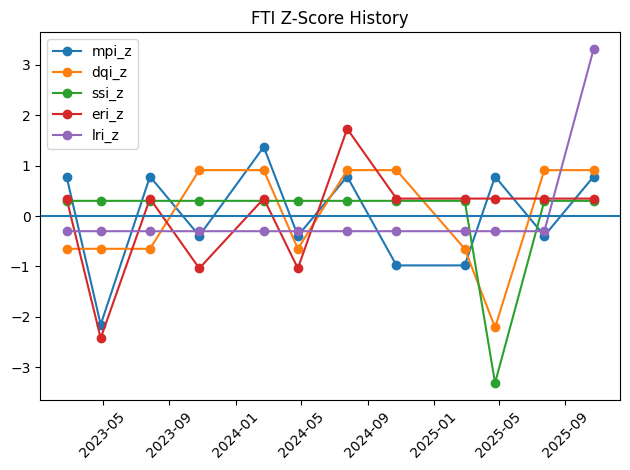

In [3]:
df = pd.read_sql("""
SELECT call_date, mpi_z, dqi_z, ssi_z, eri_z, lri_z
FROM call_zscores
WHERE ticker = 'FTI'
ORDER BY call_date;
""", conn)

df["call_date"] = pd.to_datetime(df["call_date"])

plt.figure()
for col in ["mpi_z","dqi_z","ssi_z","eri_z","lri_z"]:
    plt.plot(df["call_date"], df[col], marker="o", label=col)

plt.axhline(0)
plt.legend()
plt.title("FTI Z-Score History")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
conn.close()

